<center><h1><span style="color: green;">THỰC HÀNH BUỔI 9</span></h1></center>

# **BINARY CLASSIFICATION**

# Ví dụ 1: Phân loại ảnh Chó – Mèo bằng CNN sử dụng thư viện Keras TensorFlow.

### Chuẩn bị dữ liệu

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import tensorflow as tf
print(tf.__version__)

import warnings
warnings.filterwarnings('ignore')

2.18.0


In ra đường dẫn

In [ ]:
import os

# Đường dẫn gốc của Google Drive
drive_path = '/content/drive/MyDrive/Classroom/MachineLearning'

# Liệt kê tất cả tệp và thư mục trong thư mục gốc
for root, dirs, files in os.walk(drive_path):
    for file in files:
        # if file.endswith('.zip'):  # Chỉ hiển thị các tệp .zip
            print(os.path.join(root, file))

/content/drive/MyDrive/Classroom/MachineLearning/Hw1_22000081_NguyenTienDat.ipynb
/content/drive/MyDrive/Classroom/MachineLearning/Hw2_22000081_NguyenTienDat.ipynb
/content/drive/MyDrive/Classroom/MachineLearning/Hw3_22000081_NguyenTienDat (1).ipynb
/content/drive/MyDrive/Classroom/MachineLearning/Hw3_22000081_NguyenTienDat.ipynb
/content/drive/MyDrive/Classroom/MachineLearning/Hw4_22000081_NguyenTienDat (2).ipynb
/content/drive/MyDrive/Classroom/MachineLearning/Hw4_22000081_NguyenTienDat (1).ipynb
/content/drive/MyDrive/Classroom/MachineLearning/NguyenTienDat_22000081_BTH_0603.ipynb
/content/drive/MyDrive/Classroom/MachineLearning/Hw4_22000081_NguyenTienDat.ipynb
/content/drive/MyDrive/Classroom/MachineLearning/NguyenTienDat_22000081_BTH_1303 (1).ipynb
/content/drive/MyDrive/Classroom/MachineLearning/Hw5_22000081_NguyenTienDat.ipynb
/content/drive/MyDrive/Classroom/MachineLearning/NguyenTienDat_22000081_BTH_1303.ipynb
/content/drive/MyDrive/Classroom/MachineLearning/NguyenTienDat_2200

Giải nén dữ liệu

In [ ]:
import zipfile
# Đường dẫn đến tệp ZIP trong Google Drive
local_zip = '/content/drive/MyDrive/Classroom/MachineLearning/cats_and_dogs_filtered.zip'

# Giải nén tệp ZIP
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content/drive/MyDrive/Classroom/MachineLearning')  # Chỉ định thư mục đích để giải nén
zip_ref.close()

Thiết lập các đường dẫn đến các tệp dữ liệu

In [ ]:
import os

# Đường dẫn cơ sở đến thư mục chứa dữ liệu đã giải nén
base_dir = '/content/drive/MyDrive/Classroom/MachineLearning/cats_and_dogs_filtered'
# Change the base_dir to where you put dataset
print("Contents of base directory:")
print(os.listdir(base_dir))
print("\nContents of train directory:")
print(os.listdir(f'{base_dir}/train'))
print("\nContents of validation directory:")
print(os.listdir(f'{base_dir}/validation'))

Contents of base directory:
['vectorize.py', 'validation', 'train']

Contents of train directory:
['dogs', 'cats']

Contents of validation directory:
['dogs', 'cats']


Tham chiếu các phân lớp cho dữ liệu train và validation

In [ ]:
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
# Directory with training cat/dog pictures
train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
# Directory with validation cat/dog pictures
validation_cats_dir = os.path.join(validation_dir, 'cats')
validation_dogs_dir = os.path.join(validation_dir, 'dogs')
print("\nContents of train directory:")
print(os.listdir(f'{base_dir}/train'))
print("\nContents of validation directory:")
print(os.listdir(f'{base_dir}/validation'))


Contents of train directory:
['dogs', 'cats']

Contents of validation directory:
['dogs', 'cats']


Lấy danh sách tên file từng loại ảnh train/validation và in thử một số tên file cũng như thống kê số file ảnh mỗi phân lớp để kiểm tra


In [ ]:
train_cat_fnames = os.listdir( train_cats_dir )
train_dog_fnames = os.listdir( train_dogs_dir )
print(train_cat_fnames[:10])
print(train_dog_fnames[:10])
print('total training cat images :', len(os.listdir( train_cats_dir ) ))
print('total training dog images :', len(os.listdir( train_dogs_dir ) ))
print('total validation cat images :', len(os.listdir( validation_cats_dir ) ))
print('total validation dog images :', len(os.listdir( validation_dogs_dir ) ))

['cat.127.jpg', 'cat.126.jpg', 'cat.125.jpg', 'cat.124.jpg', 'cat.123.jpg', 'cat.122.jpg', 'cat.121.jpg', 'cat.120.jpg', 'cat.119.jpg', 'cat.118.jpg']
['dog.127.jpg', 'dog.126.jpg', 'dog.125.jpg', 'dog.124.jpg', 'dog.123.jpg', 'dog.122.jpg', 'dog.121.jpg', 'dog.120.jpg', 'dog.119.jpg', 'dog.118.jpg']
total training cat images : 1000
total training dog images : 1000
total validation cat images : 500
total validation dog images : 500


 Thử in ra một số ảnh của mỗi loại để kiểm tra

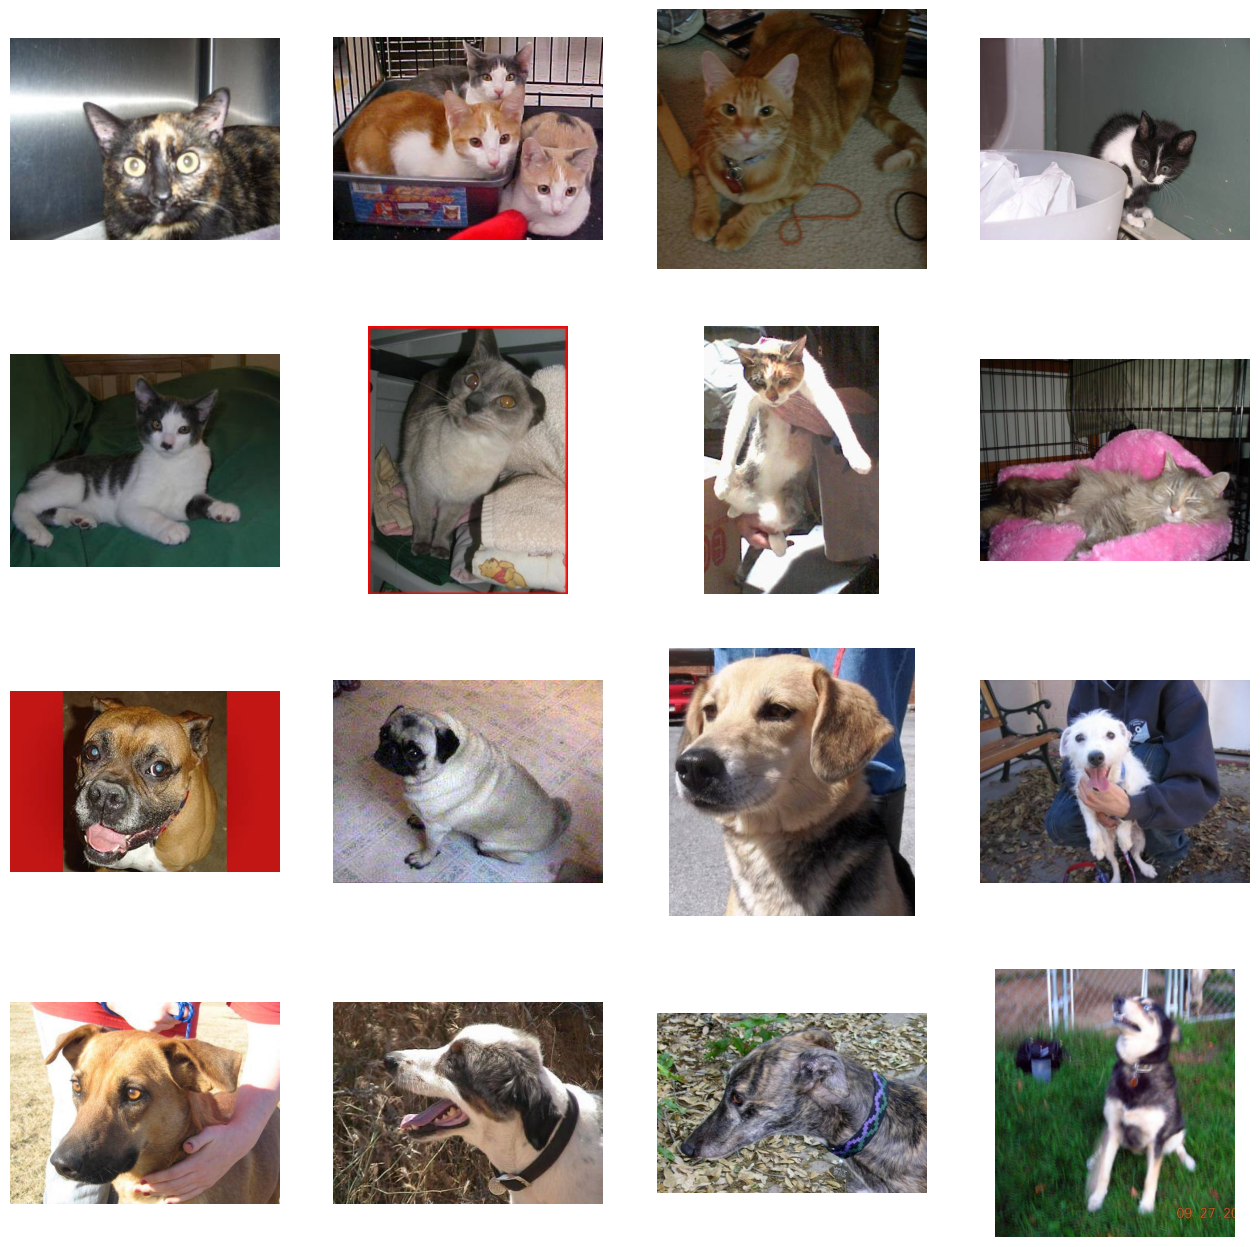

In [ ]:
%matplotlib inline
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

# Parameters for our graph; we'll output images in a 4x4 configuration
nrows = 4
ncols = 4

pic_index = 0 # Index for iterating over images
# Set up matplotlib fig, and size it to fit 4x4 pics
fig = plt.gcf()
fig.set_size_inches(ncols*4, nrows*4)

pic_index+=8

next_cat_pix = [os.path.join(train_cats_dir, fname)
                for fname in train_cat_fnames[ pic_index-8:pic_index]
                ]

next_dog_pix = [os.path.join(train_dogs_dir, fname)
                for fname in train_dog_fnames[ pic_index-8:pic_index]
                ]

for i, img_path in enumerate(next_cat_pix+next_dog_pix):
  # Set up subplot; subplot indices start at 1
  sp = plt.subplot(nrows, ncols, i + 1)
  sp.axis('Off') # Don't show axes (or gridlines)
  img = mpimg.imread(img_path)
  plt.imshow(img)

plt.show()


### Khởi tạo mô hình CNN

Chúng ta sẽ sử dụng một mô hình CNN từ thư viện TensorFlow, với kiến trúc như sau:
- 03 tầng tích chập (convolution layers) kết hợp với Pooling (MaxPooling layers), kích thước mặt nạ tích
chập là 3x3, kích thước pooling là 2x2.
- Sau mỗi tầng tích chập, hàm kích hoạt được sử dụng là ReLU.
- Tiếp theo là một tầng Full Connection và tầng tiếp theo là Flatten (duỗi các kết quả đầu ra thành vector).
- Cuối cùng là một tầng phân loại ở đầu ra, sử dụng hàm Sigmoid (logistic – vì đây chỉ có 02 lớp)

Khởi tạo một CNN như trên:

In [ ]:
import tensorflow as tf
model = tf.keras.models.Sequential([
  # Note the input shape is the desired size of the image 150x150 with 3 bytes color
  tf.keras.layers.InputLayer(shape=[150, 150, 3]), # Specify the input shape
  tf.keras.layers.Conv2D(16, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),
  # Flatten the results to feed into a DNN
  tf.keras.layers.Flatten(),
  # 512 neuron hidden layer
  tf.keras.layers.Dense(512, activation='relu'),
  # Only 1 output neuron.
  # It will contain a value from 0-1 where 0 for 1 class ('cats')
  # and 1 for the other ('dogs')
  tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 18496)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       9,470,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,494,561 (36.22 MB)

 Trainable params: 9,494,561 (36.22 MB)

 Non-trainable params: 0 (0.00 B)

### Huấn luyện mô hình

Trước hết ta thiết lập phương pháp giải bài toán tối ưu. Ở đây ta dùng RMSprop thay cho SGD (do có thể tự động chọn tham số học)

In [ ]:
from tensorflow.keras.optimizers import RMSprop
model.compile(optimizer=RMSprop(learning_rate=0.001),
 loss='binary_crossentropy',
 metrics = ['accuracy'])

Chuẩn hóa dữ liệu bằng các đưa cường độ pixel về khoảng [0, 1], chỉnh kích thước ảnh về 150x150 và điều hướng các thư mục chứa dữ liệu training

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# All images will be rescaled by 1./255.
train_datagen = ImageDataGenerator( rescale = 1.0/255. )
test_datagen = ImageDataGenerator( rescale = 1.0/255. )

# --------------------
# Flow training images in batches of 20 using train_datagen generator
# --------------------
train_generator = train_datagen.flow_from_directory(train_dir,
                                                    batch_size=20,
                                                    class_mode='binary',
                                                    target_size=(150, 150))
# --------------------
# Flow validation images in batches of 20 using test_datagen generator
# --------------------
validation_generator = test_datagen.flow_from_directory(validation_dir,
                                                        batch_size=20,
                                                        class_mode = 'binary',
                                                        target_size = (150, 150))

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


Huấn luyện mô hình

In [ ]:
ory = model.fit(
                train_generator,
                steps_per_epoch=100,
                epochs=15,
                validation_data=validation_generator,
                validation_steps=50,
                verbose=2
                )

Epoch 1/15
100/100 - 76s - 757ms/step - accuracy: 0.6080 - loss: 0.6799 - val_accuracy: 0.6610 - val_loss: 0.6336
Epoch 2/15
100/100 - 86s - 857ms/step - accuracy: 0.6725 - loss: 0.6196 - val_accuracy: 0.5960 - val_loss: 0.6834
Epoch 3/15
100/100 - 77s - 774ms/step - accuracy: 0.7260 - loss: 0.5484 - val_accuracy: 0.5260 - val_loss: 1.2478
Epoch 4/15
100/100 - 90s - 896ms/step - accuracy: 0.7640 - loss: 0.4840 - val_accuracy: 0.7570 - val_loss: 0.5519
Epoch 5/15
100/100 - 136s - 1s/step - accuracy: 0.8125 - loss: 0.4054 - val_accuracy: 0.7180 - val_loss: 0.6179
Epoch 6/15
100/100 - 73s - 726ms/step - accuracy: 0.8545 - loss: 0.3283 - val_accuracy: 0.7230 - val_loss: 0.5939
Epoch 7/15
100/100 - 89s - 885ms/step - accuracy: 0.9075 - loss: 0.2258 - val_accuracy: 0.6950 - val_loss: 0.9062
Epoch 8/15
100/100 - 75s - 748ms/step - accuracy: 0.9400 - loss: 0.1993 - val_accuracy: 0.7190 - val_loss: 0.6847
Epoch 9/15
100/100 - 76s - 760ms/step - accuracy: 0.9645 - loss: 0.1038 - val_accuracy: 0.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step


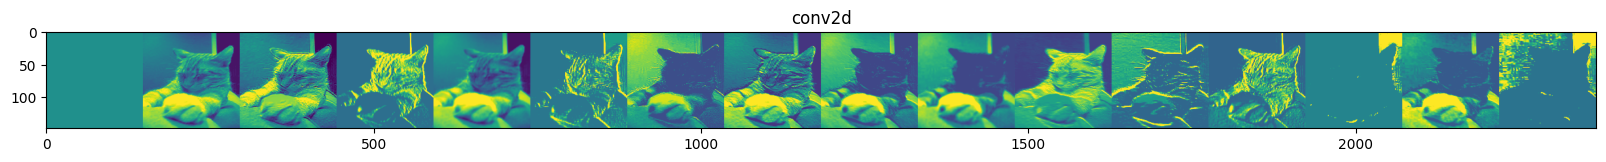

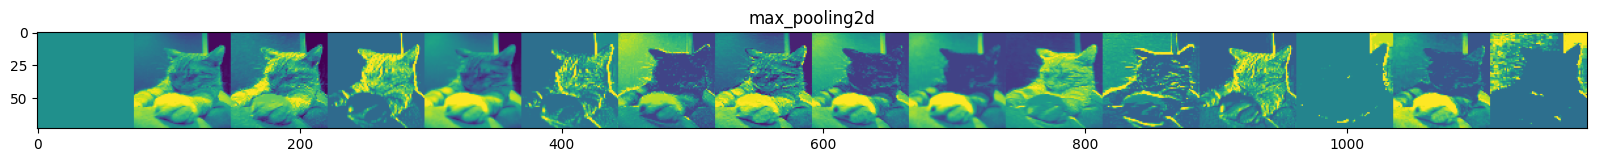

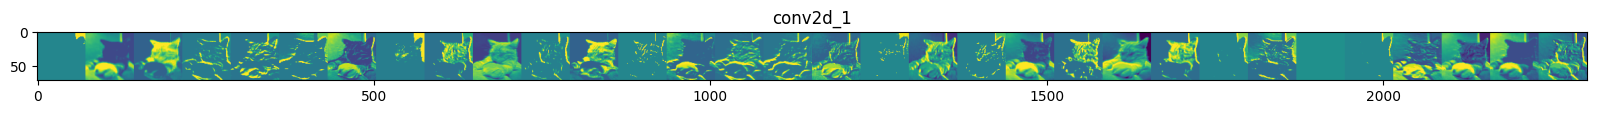

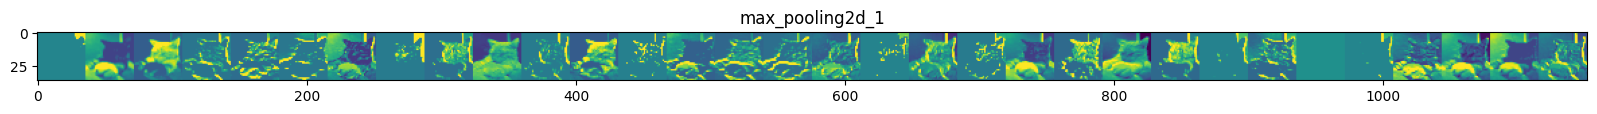

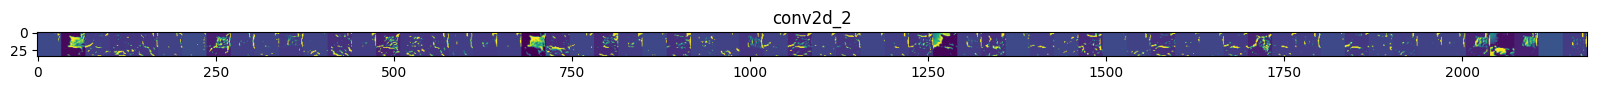

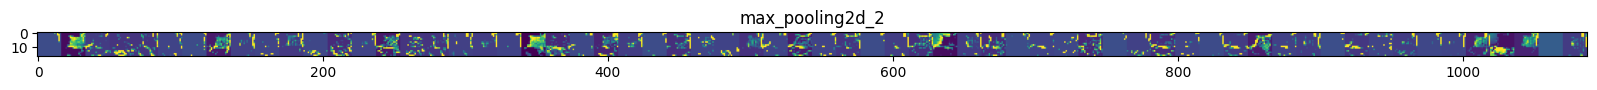

In [ ]:
import numpy as np
import random
from tensorflow.keras.preprocessing.image import img_to_array, load_img

# Define a new Model that will take an image as input, and will output
# intermediate representations for all layers in the previous model
successive_outputs = [layer.output for layer in model.layers]
model(tf.keras.Input((150, 150, 3)))
visualization_model = tf.keras.models.Model([model.inputs], outputs =successive_outputs)
# Prepare a random input image from the training set.
cat_img_files = [os.path.join(train_cats_dir, f) for f in train_cat_fnames]
dog_img_files = [os.path.join(train_dogs_dir, f) for f in train_dog_fnames]
img_path = random.choice(cat_img_files + dog_img_files)
img = load_img(img_path, target_size=(150, 150)) # this is a PIL image
x = img_to_array(img) # Numpy array with shape (150, 150,3)
x = x.reshape((1,) + x.shape) # Numpy array with shape (1, 150,150, 3)
# Scale by 1/255
x /= 255.0
# Run the image through the network, thus obtaining all
# intermediate representations for this image.
successive_feature_maps = visualization_model.predict(x) # These are the names of the layers, so we can have them as part of our plot
layer_names = [layer.name for layer in model.layers]
# Display the representations
for layer_name, feature_map in zip(layer_names, successive_feature_maps):
    if len(feature_map.shape) == 4:
      #-------------------------------------------
      # Just do this for the conv / maxpool layers, not the fully-connected layers
      #-------------------------------------------
      n_features = feature_map.shape[-1] # number of features in the feature map
      size = feature_map.shape[ 1] # feature map shape (1, size, size, n_features)
      # Tile the images in this matrix
      display_grid = np.zeros((size, size * n_features))
      #-------------------------------------------------
      # Postprocess the feature to be visually palatable
      #-------------------------------------------------
      for i in range(n_features):
          x = feature_map[0, :, :, i]
          x -= x.mean()
          if (x.std () != 0):
              x /= x.std ()
          x *= 64
          x += 128
          x = np.clip(x, 0, 255).astype('uint8')
          display_grid[:, i * size : (i + 1) * size] = x
      # Tile each filter into a horizontal grid
      #-----------------
      # Display the grid
      #-----------------
      scale = 20. / n_features
      plt.figure( figsize=(scale * n_features, scale) )
      plt.title ( layer_name )
      plt.grid ( False )
      plt.imshow( display_grid, aspect='auto', cmap='viridis' )


Trong đoạn lệnh trên, chúng ta sẽ in ra kết quả sau mỗi tầng (“ảnh” đầu ra sau mỗi tầng convolution và maxpool) để hiểu thêm cách hoạt động của CNN để cho ra dãy so sánh được ở tầng flatten. Chú ý đoạn lệnh này có thể phát sinh lỗi đồi với một vài phương thức trong thư viện phiên bản cao của TensorFlow.

Đoạn lệnh tiếp theo chúng ta thử sử dụng mô hình với các tham số đã được huấn
luyện (train) để dự đoán (predict) cho một số ảnh đầu vào tùy ý (chú ý cần có chó hoặc mèo). Chúng ta hãy sửa đoạn lệnh này để áp dụng cho một list các tên file ảnh đầu vào, thay vì từng ảnh như trong hướng dẫn.

In [ ]:
import numpy as np

#from google.colab import files
from keras.preprocessing import image

#uploaded=files.upload()

#for fn in uploaded.keys():
fn = 'IMG_5425.PNG' # change it to your image file

# predicting images
path = "/content/drive/MyDrive/Classroom/MachineLearning/IMG_5425.PNG"
img=image.load_img(path, target_size=(150, 150))

x=image.img_to_array(img)
x /= 255
x=np.expand_dims(x, axis=0)
images = np.vstack([x])

classes = model.predict(images, batch_size=10)

print(classes[0])

if classes[0]>0.5:
 print(fn + " is a dog" )
else:
 print(fn + " is a cat" )


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
[0.9993812]
IMG_5425.PNG is a dog


Tính toán các độ đo độ chính xác (accuracy) và hàm tổn thất, sau đó vẽ đồ thị để minh họa

Text(0.5, 1.0, 'Training and validation loss')

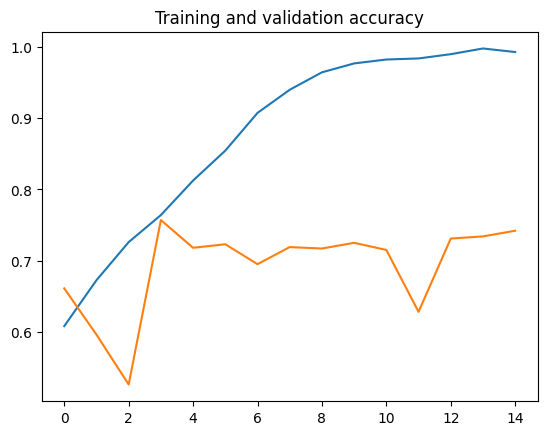

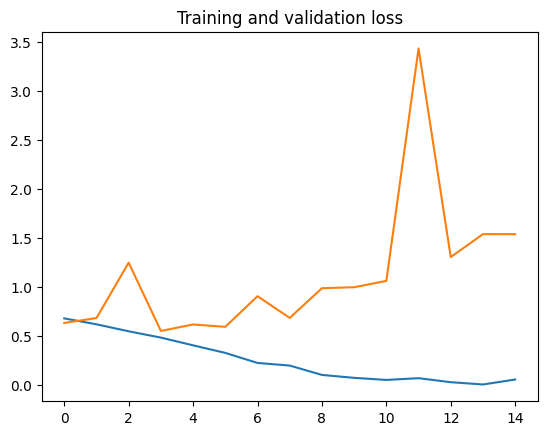

In [ ]:
#-----------------------------------------------------------
# Retrieve a list of list results on training and test data
# sets for each training epoch
#-----------------------------------------------------------
acc = ory.history[ 'accuracy' ] # Access the 'accuracy' key within the history dictionary
val_acc = ory.history[ 'val_accuracy' ] # Access the 'val_accuracy' key within the history dictionary
loss = ory.history[ 'loss' ] # Access the 'loss' key within the history dictionary
val_loss = ory.history['val_loss' ] # Access the 'val_loss' key within the history dictionary

epochs = range(len(acc)) # Get number of epochs

#------------------------------------------------
# Plot training and validation accuracy per epoch
#------------------------------------------------
plt.plot ( epochs, acc )
plt.plot ( epochs, val_acc )
plt.title ('Training and validation accuracy')
plt.figure()
#------------------------------------------------
# Plot training and validation loss per epoch
#------------------------------------------------
plt.plot ( epochs, loss )
plt.plot ( epochs, val_loss )
plt.title ('Training and validation loss' )

**1. Quan sát Loss Function và Accuracy trên tập Training và trên tập Validation. Giải thích những kết quả quan sát được.**

- Độ chính xác: Tập huấn luyện (xanh) tăng đều, đạt gần 1.0; tập kiểm tra (cam) dao động quanh 0.7, cho thấy quá khớp (overfitting).
- Hàm mất mát: Tập huấn luyện (xanh) giảm về gần 0; tập kiểm tra (cam) tăng đột biến, biến động mạnh, xác nhận mô hình không tổng quát hóa tốt.

**2.Trong thư viện tensorflow.keras.layer có một loại layer là Dropout(rate = <rate_drop>), trong đó giá trị của rate_drop thuộc [0, 1). Layer Dropout cho phép bỏ bớt dữ liệu train với tỉ lệ là rate_drop, nhằm mục đích tránh overfit. Hãy bổ sung các tầng Dropout này vào giữa các tầng Convolution, rate_drop khoảng từ 0.3 đến 0.5 và quan sát kết quả sau khi thay đổi.**


In [ ]:
import tensorflow as tf

model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.3), # Dropout layer after the first Conv2D layer
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.4), # Dropout layer after the second Conv2D layer
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.5), # Dropout layer after the third Conv2D layer
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     9,470,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,494,561 (36.22 MB)

 Trainable params: 9,494,561 (36.22 MB)

 Non-trainable params: 0 (0.00 B)

# **MULTINOMIAL CLASSIFICATION**

## Ví dụ 2. Phân loại ảnh Chó – Mèo – Gấu trúc bằng CNN sử dụng thư viện Keras TensorFlow

In [1]:
import os
import numpy as np # linear algebra
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import PIL
import PIL.Image
from tensorflow import keras
import tensorflow_datasets as tfds

In [3]:
pip install rarfile

In [4]:
import rarfile

# Đường dẫn đến tệp RAR trong Google Drive
local_rar = '/content/drive/MyDrive/Classroom/MachineLearning/CNN_MultiClass_data.rar'

# Giải nén tệp RAR
rar_ref = rarfile.RarFile(local_rar, 'r')
rar_ref.extractall('/content/drive/MyDrive/Classroom/MachineLearning')  # Chỉ định thư mục đích để giải nén
rar_ref.close()

**Khởi dựng mô hình CNN với kiến trúc gồm:**

* 3 tầng Convolution & MaxPooling nối tiếp: Tầng đầu gồm 16 filters; Tầng 2 gồm 32 filters và tầng ba gồm 64 filters, tất cả có cùng cỡ 3x3;
* Tiếp theo tầng Convolution thứ ba là tầng Flatten;
* Tiếp theo đó ta có tầng FullyConnected (FullConnection) FC với đầu ra là vector đặc trưng 512 phần tử. Tất cả các tầng Conv và FC đều sử dụng activation là ReLU;
* Cuối cùng, ta có tầng đầu ra với activation là SoftMax chia 03 loại.

In [5]:
# Trains a model to classify images of 3 classes: cat, dog, and panda.
def gen_model():

    # Defines & compiles the model
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(150, 150,
3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    keras.layers.Dropout(rate=0.15), #adding dropout regularization throughout the model to deal with overfitting
    # The second convolution
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    keras.layers.Dropout(rate=0.1),
    # The third convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    keras.layers.Dropout(rate=0.10),
    # Flatten the results to feed into a DNN
    tf.keras.layers.Flatten(),
    # 512 neuron hidden layer
    tf.keras.layers.Dense(512, activation='relu'),

    # 3 output neuron for the 3 classes of Animal Images
    tf.keras.layers.Dense(3, activation='softmax')
    ])

    from tensorflow.keras.optimizers import RMSprop

    model.compile(loss='categorical_crossentropy',
    optimizer="adam",
    metrics=['acc'])
    return model

Thiết lập dữ liệu và gọi mô hình để huấn luyện và dự báo

In [8]:
# Trains a model to classify images of 3 classes: cat, dog, and panda
def train_test_animals():
    # Creates an instance of an ImageDataGenerator called train_datagen, and a train_generator, train_datagen.flow_from_directory

    from tensorflow.keras.preprocessing.image import ImageDataGenerator

    #splits data into training and testing(validation) sets
    train_datagen =ImageDataGenerator(rescale=1./255, validation_split=0.25)

    import matplotlib.pyplot as plt

    #training data
    train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Classroom/MachineLearning/CNN_MultiClass_data/animals',
    # Source directory
    target_size=(150, 150), # Resizes images
    batch_size=15,
    class_mode='categorical',subset = 'training')

    epochs = 2
    #Testing data
    validation_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Classroom/MachineLearning/CNN_MultiClass_data/validation',
    target_size=(150, 150),
    batch_size=15,
    class_mode='categorical',
    subset='validation') # set as validation data

    model = gen_model()
    #Model fitting for a number of epochs
    # Replacing model.fit_generator with model.fit
    history = model.fit(
    train_generator,
    steps_per_epoch=150,
    epochs=epochs,
    validation_data = validation_generator,
    validation_steps = 50,
    verbose=1)



    acc = history.history['acc']
    val_acc = history.history['val_acc']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    #This code is used to plot the training and validation accuracy
    epochs_range = range(epochs)
    plt.figure(figsize=(8, 8))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()
    # returns accuracy of training
    print("Training Accuracy:"), print(history.history['acc'][-1])
    print("Testing Accuracy:"), print (history.history['val_acc'][-1])

Found 2250 images belonging to 3 classes.
Found 750 images belonging to 3 classes.
Epoch 1/2
150/150 ━━━━━━━━━━━━━━━━━━━━ 93s 599ms/step - acc: 0.5007 - loss: 1.3495 - val_acc: 0.5440 - val_loss: 0.8269
Epoch 2/2
150/150 ━━━━━━━━━━━━━━━━━━━━ 141s 596ms/step - acc: 0.6404 - loss: 0.7000 - val_acc: 0.5760 - val_loss: 0.8006


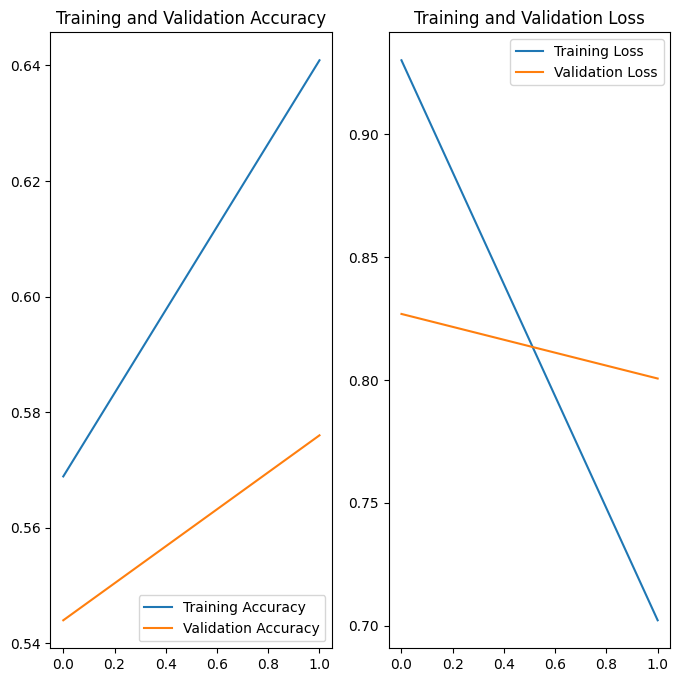

Training Accuracy:
0.6408888697624207
Testing Accuracy:
0.5759999752044678


In [10]:
import warnings
warnings.filterwarnings('ignore')

train_test_animals()

**Nhận xét về độ chính xác:**

* Độ chính xác huấn luyện và xác thực đều tăng lên theo thời gian, điều này là một dấu hiệu tốt cho thấy mô hình đang học.
* Độ chính xác xác thực thấp hơn độ chính xác huấn luyện, điều này là bình thường, nhưng khoảng cách giữa chúng không quá lớn, cho thấy mô hình không bị quá khớp (overfitting).

**Nhận xét về mất mát:**

* Mất mát huấn luyện và xác thực đều giảm theo thời gian, điều này cho thấy mô hình đang cải thiện.
* Mất mát xác thực cao hơn mất mát huấn luyện, điều này là bình thường, nhưng chúng có xu hướng hội tụ, cho thấy mô hình đang học tốt.

**Nhận xét chung:**

* Mô hình đang học tốt và không có dấu hiệu bị quá khớp.

## Ví dụ 3:  Sử dụng bộ ảnh dữ liệu các khuôn mặt facedata với 11 phân loại. Chia dữ liệu thành các tập train:test tỷ lệ 8:2. Sau đó huấn luyện mô hình CNN đơn giản và thực hiện dự đoán cho tập test.

In [31]:
import zipfile
import os
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# 1. Giải nén dữ liệu
local_zip = '/content/drive/MyDrive/Classroom/MachineLearning/yalefaces_data.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content/drive/MyDrive/Classroom/MachineLearning')
zip_ref.close()

In [28]:
# 2. Đọc và tiền xử lý dữ liệu
def load_data(data_path):
    ids = range(1, 16)  # 15 người
    states = ['centerlight', 'glasses', 'happy', 'leftlight',
              'noglasses', 'normal', 'rightlight', 'sad',
              'sleepy', 'surprised', 'wink']
    prefix = 'subject'
    surfix = '.png'

    images = []
    labels = []

    for person_id in ids:
        for state in states:
            fn = os.path.join(data_path, f"{prefix}{str(person_id).zfill(2)}.{state}{surfix}")
            img = cv2.imread(fn, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, (64, 64))
                images.append(img)
                labels.append(person_id - 1)  # Nhãn từ 0 đến 14
            else:
                print(f"Không thể đọc ảnh: {fn}")

    images = np.array(images)
    labels = np.array(labels)
    images = images.astype('float32') / 255.0
    images = images.reshape(-1, 64, 64, 1)

    class_names = [f"subject{str(i).zfill(2)}" for i in range(1, 16)]
    print(f"Tổng số ảnh: {len(images)}, Số nhãn: {len(labels)}")
    return images, labels, class_names

# Đường dẫn dữ liệu
data_path = '/content/drive/MyDrive/Classroom/MachineLearning/yalefaces_data'
X, y, class_names = load_data(data_path)

if len(X) == 0:
    print("Không đọc được dữ liệu!")
    exit()

Không thể đọc ảnh: /content/drive/MyDrive/Classroom/MachineLearning/yalefaces_data/subject01.centerlight.png
Tổng số ảnh: 164, Số nhãn: 164


### 1. Xây dựng và huấn luyện mô hình CNN, tính các độ đo Accuracy, Precision, Recall trên tập train và test.

In [29]:
# 3. Chia dữ liệu train:test = 8:2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Kích thước tập train: {X_train.shape}")
print(f"Kích thước tập test: {X_test.shape}")

# 4. Xây dựng và huấn luyện mô hình CNN
cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(15, activation='softmax')  # 15 người
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Huấn luyện
cnn_history = cnn_model.fit(X_train, y_train,
                            epochs=20,
                            batch_size=32,
                            validation_split=0.2,
                            verbose=1)

Kích thước tập train: (131, 64, 64, 1)
Kích thước tập test: (33, 64, 64, 1)
Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 264ms/step - accuracy: 0.1345 - loss: 2.7121 - val_accuracy: 0.0741 - val_loss: 2.7288
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step - accuracy: 0.1118 - loss: 2.6364 - val_accuracy: 0.2222 - val_loss: 2.6261
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 299ms/step - accuracy: 0.2754 - loss: 2.4147 - val_accuracy: 0.3333 - val_loss: 2.3789
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 276ms/step - accuracy: 0.3047 - loss: 2.2056 - val_accuracy: 0.6296 - val_loss: 1.9637
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 288ms/step - accuracy: 0.5437 - loss: 1.7835 - val_accuracy: 0.5556 - val_loss: 1.6023
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.5676 - loss: 1.4287 - val_accuracy: 0.6296 - val_loss: 1.3339
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.5276 - loss: 1.4840 - val_accuracy: 0.7037 - val_loss: 1.0619
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 163

In [35]:
# Dự đoán trên tập train và test
y_train_pred_cnn = cnn_model.predict(X_train)
y_train_pred_cnn_classes = np.argmax(y_train_pred_cnn, axis=1)
y_test_pred_cnn = cnn_model.predict(X_test)
y_test_pred_cnn_classes = np.argmax(y_test_pred_cnn, axis=1)

# Tính các độ đo
train_accuracy_cnn = accuracy_score(y_train, y_train_pred_cnn_classes)
train_precision_cnn = precision_score(y_train, y_train_pred_cnn_classes, average='weighted', zero_division=0)
train_recall_cnn = recall_score(y_train, y_train_pred_cnn_classes, average='weighted', zero_division=0)

test_accuracy_cnn = accuracy_score(y_test, y_test_pred_cnn_classes)
test_precision_cnn = precision_score(y_test, y_test_pred_cnn_classes, average='weighted', zero_division=0)
test_recall_cnn = recall_score(y_test, y_test_pred_cnn_classes, average='weighted', zero_division=0)

print("\nĐộ đo mô hình CNN:")
print("Tập train:")
print(f"Accuracy: {train_accuracy_cnn:.4f}")
print(f"Precision: {train_precision_cnn:.4f}")
print(f"Recall: {train_recall_cnn:.4f}")
print("\nTập test:")
print(f"Accuracy: {test_accuracy_cnn:.4f}")
print(f"Precision: {test_precision_cnn:.4f}")
print(f"Recall: {test_recall_cnn:.4f}")

# Báo cáo chi tiết và ma trận nhầm lẫn
print("\nBáo cáo phân loại tập test (CNN):")
print(classification_report(y_test, y_test_pred_cnn_classes, target_names=class_names))


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

Độ đo mô hình CNN:
Tập train:
Accuracy: 0.9847
Precision: 0.9863
Recall: 0.9847

Tập test:
Accuracy: 0.9091
Precision: 0.9394
Recall: 0.9091

Báo cáo phân loại tập test (CNN):
              precision    recall  f1-score   support

   subject01       0.67      1.00      0.80         2
   subject02       1.00      1.00      1.00         2
   subject03       0.67      1.00      0.80         2
   subject04       1.00      1.00      1.00         2
   subject05       1.00      1.00      1.00         3
   subject06       1.00      1.00      1.00         2
   subject07       1.00      1.00      1.00         2
   subject08       1.00      0.67      0.80         3
   subject09       1.00      1.00      1.00         2
   subject10       0.67      1.00      0.80         2
   subject11       1.00      1.00      1.00         2
   subject12       1.00      0.67      0.80         3
   subject13       1.00      1.00      1.00

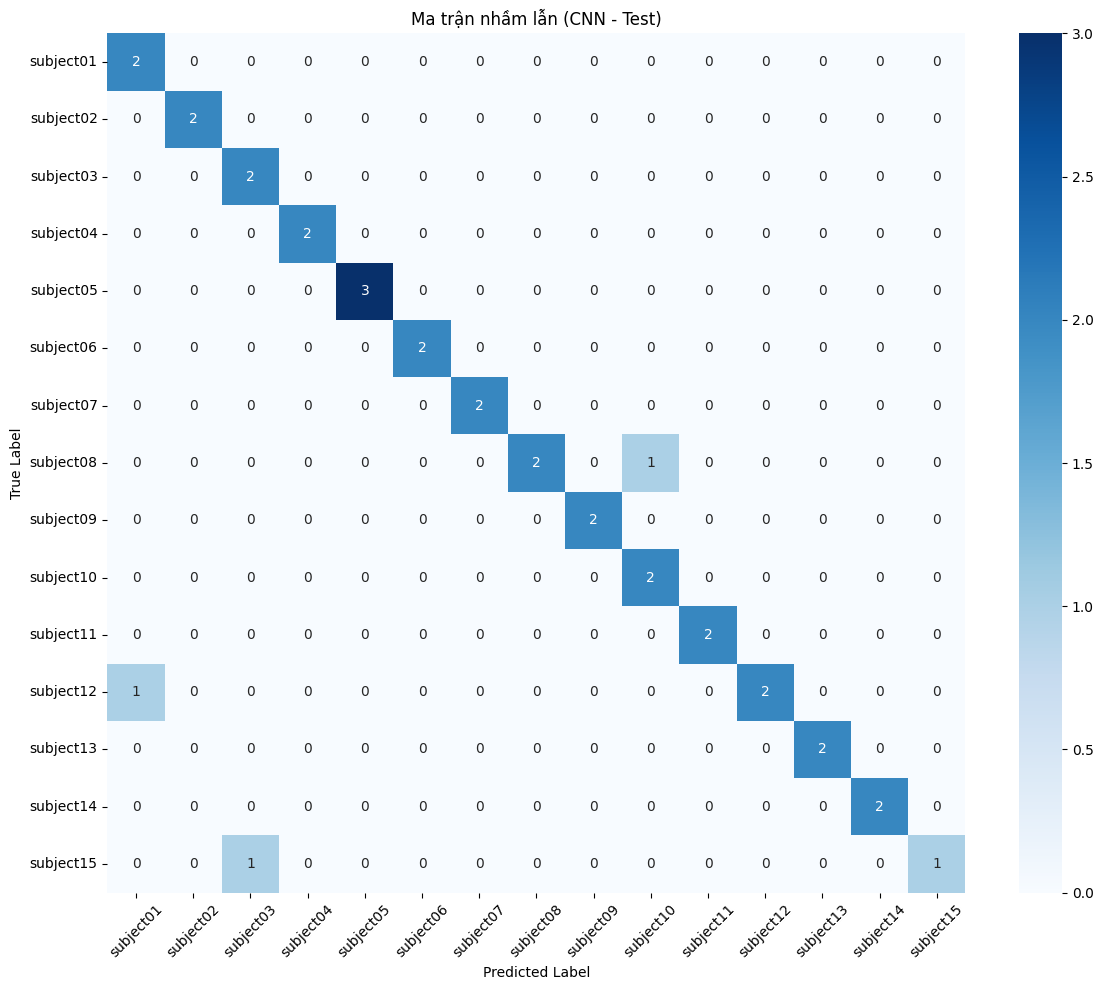

In [36]:
cm_cnn = confusion_matrix(y_test, y_test_pred_cnn_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Ma trận nhầm lẫn (CNN - Test)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

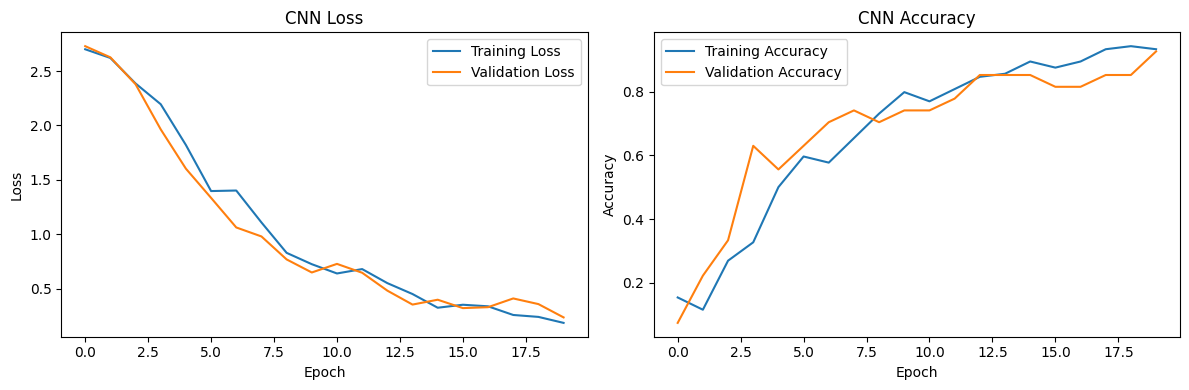

In [37]:
# Vẽ biểu đồ loss và accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

#### Nhận xét:
**Mất mát (Loss):**

* Mất mát huấn luyện và mất mát kiểm định đều giảm theo số lượng epoch, cho thấy mô hình đang học tốt.
* Mất mát kiểm định cao hơn một chút so với mất mát huấn luyện, điều này là bình thường, nhưng khoảng cách giữa chúng không quá lớn, cho thấy mô hình không bị quá khớp (overfitting).

**Độ chính xác (Accuracy):**

* Độ chính xác huấn luyện và độ chính xác kiểm định đều tăng theo số lượng epoch, cho thấy mô hình đang cải thiện hiệu suất.
* Độ chính xác kiểm định gần như tương đương với độ chính xác huấn luyện, điều này cho thấy mô hình tổng quát hóa tốt trên dữ liệu chưa thấy.

**Nhận xét chung:**

* Mô hình đang học tốt và không có dấu hiệu bị quá khớp.



Độ đo mô hình PCA + Logistic Regression:
Tập train:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000

Tập test:
Accuracy: 0.9091
Precision: 0.9394
Recall: 0.9091

Báo cáo phân loại tập test (PCA + Logistic):
              precision    recall  f1-score   support

   subject01       0.67      1.00      0.80         2
   subject02       1.00      1.00      1.00         2
   subject03       1.00      0.50      0.67         2
   subject04       1.00      0.50      0.67         2
   subject05       1.00      1.00      1.00         3
   subject06       1.00      1.00      1.00         2
   subject07       0.67      1.00      0.80         2
   subject08       1.00      1.00      1.00         3
   subject09       0.67      1.00      0.80         2
   subject10       1.00      1.00      1.00         2
   subject11       1.00      1.00      1.00         2
   subject12       1.00      1.00      1.00         3
   subject13       1.00      1.00      1.00         2
   subject14       1.00      1.00

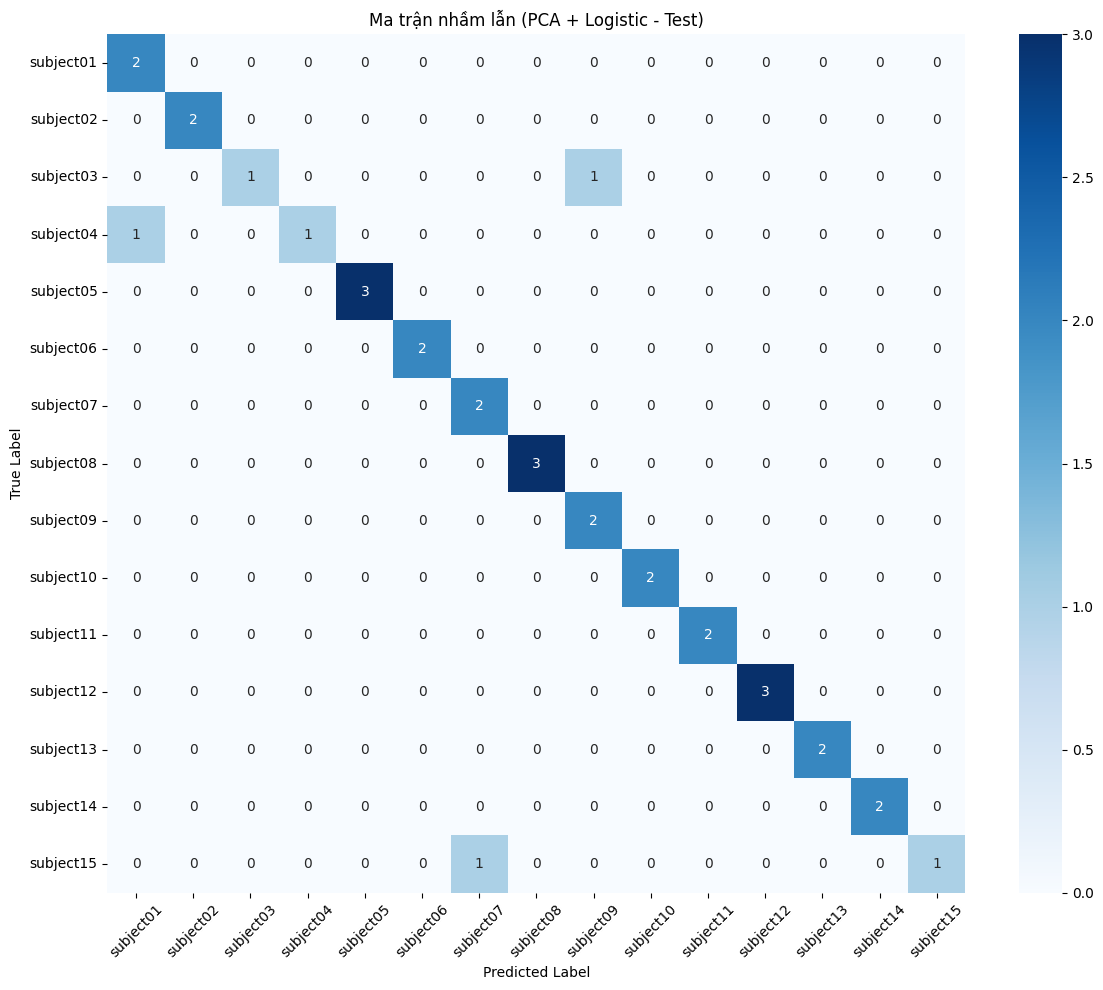

In [39]:
# Mô hình PCA + Logistic Regression
# Chuẩn bị dữ liệu cho PCA
X_flat = X.reshape(len(X), -1)  # Chuyển thành (N, 64*64)
pca = PCA(n_components=135)
X_reduced = pca.fit_transform(X_flat)
X_train_reduced, X_test_reduced, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

# Huấn luyện Logistic Regression
lr_model = LogisticRegression(multi_class='multinomial', max_iter=1000)
lr_model.fit(X_train_reduced, y_train)

# Đánh giá
y_train_pred_lr = lr_model.predict(X_train_reduced)
y_test_pred_lr = lr_model.predict(X_test_reduced)

train_accuracy_lr = accuracy_score(y_train, y_train_pred_lr)
train_precision_lr = precision_score(y_train, y_train_pred_lr, average='weighted', zero_division=0)
train_recall_lr = recall_score(y_train, y_train_pred_lr, average='weighted', zero_division=0)

test_accuracy_lr = accuracy_score(y_test, y_test_pred_lr)
test_precision_lr = precision_score(y_test, y_test_pred_lr, average='weighted', zero_division=0)
test_recall_lr = recall_score(y_test, y_test_pred_lr, average='weighted', zero_division=0)

print("\nĐộ đo mô hình PCA + Logistic Regression:")
print("Tập train:")
print(f"Accuracy: {train_accuracy_lr:.4f}")
print(f"Precision: {train_precision_lr:.4f}")
print(f"Recall: {train_recall_lr:.4f}")
print("\nTập test:")
print(f"Accuracy: {test_accuracy_lr:.4f}")
print(f"Precision: {test_precision_lr:.4f}")
print(f"Recall: {test_recall_lr:.4f}")

print("\nBáo cáo phân loại tập test (PCA + Logistic):")
print(classification_report(y_test, y_test_pred_lr, target_names=class_names))

cm_lr = confusion_matrix(y_test, y_test_pred_lr)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Ma trận nhầm lẫn (PCA + Logistic - Test)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Nhận xét chung:**

* **Độ chính xác cao:** Mô hình có độ chính xác cao, thể hiện qua đường chéo chính có giá trị lớn và các ô ngoài đường chéo có giá trị nhỏ hoặc bằng 0.
* **Tổng quát hóa tốt:** Mô hình tổng quát hóa tốt trên dữ liệu kiểm tra, vì độ chính xác trên dữ liệu kiểm tra gần như tương đương với độ chính xác trên dữ liệu huấn luyện.
* **Phân loại tốt:** Mô hình phân loại tốt tất cả các lớp, thể hiện qua các ô trên đường chéo chính có giá trị lớn.
* **Ít nhầm lẫn:** Mô hình ít nhầm lẫn giữa các lớp, thể hiện qua các ô ngoài đường chéo chính có giá trị nhỏ hoặc bằng 0.

**Kết luận:**

Mô hình hoạt động tốt và có độ chính xác cao. Tuy nhiên, có một vài trường hợp nhầm lẫn giữa các lớp, đặc biệt là giữa Subject03 và Subject08, Subject04 và Subject01, Subject15 và Subject06.